# Environment Setup

## PIP

In [4]:
!pip install colour
!pip install matplotlib
!pip install pandas
!pip install utm


## Imports

In [18]:

import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
import glob
import os
import datetime



## Functions

In [6]:
def windAnalysis(heading,windDirection, windSpeed):
    newWindDirections = []
    newWindSpeeds = []
    for i in range(0,windDirection.__len__()):
        if(windDirection[i] == 'nan' or heading[i] == 'NaN'):
            a = 1 
        elif(float(windDirection[i]) < 0):
            windScaled = 360+float(windDirection[i])
            windMagnetic = windScaled + float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))
        elif(float(windDirection[i]) > 0):
            windMagnetic = float(windDirection[i]) +float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))

    for i in range(0,windSpeed.__len__()):
        if(windSpeed[i] == 'nan'):
            a = 1 
        elif(float(windSpeed[i]) < 0):
            newWindSpeeds.append(float(windSpeed[i]))
        elif(float(windSpeed[i]) > 0):
            newWindSpeeds.append(float(windSpeed[i]))
        

    ## Calculate Average Wind Direction and Speed and put in a bin
    totalDirection = 0
    totalSpeed = 0
    for i in range(0,newWindDirections.__len__()):
        totalDirection += newWindDirections[i]

    for i in range(0,newWindSpeeds.__len__()):
        totalSpeed += float(newWindSpeeds[i])


    avgDirection = totalDirection/newWindDirections.__len__() 
    avgSpeed = totalSpeed/newWindSpeeds.__len__()
    if math.isnan(avgDirection):
        avgDirection = 0
    return [avgDirection,avgSpeed]

# Data Ingestion

In [7]:
aircraft = "Cessna_172S_flight_"
dfArray = []
for x in range(1,101):
    new_df = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}{x}.csv')
    dfArray.append(new_df)

# df = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}1.csv')
# df2 = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}2574.csv')
dfArray[0].head()
dfArray.__len__()

100

# Wind Direction Batch

In [8]:
directionBins = [[] for _ in range(361)]
speedBins = [[] for _ in range(50)]
for i in range(0,90):
    currdf = dfArray[i]
    if (' WndDr' in currdf) and (' WndSpd' in currdf) and (' HDG' in currdf):
        averages = windAnalysis(currdf[' HDG'],currdf[' WndDr'],currdf[' WndSpd'])
        destinationBin = int(math.floor(averages[0]))
        speedBin = int(math.floor(averages[1]))
        # print(math.floor(averages[0]))
        print(destinationBin, "--" , i,"speed",speedBin )
        directionBins[destinationBin].append(i)
        speedBins[speedBin].append(i)


150 -- 0 speed 11
157 -- 1 speed 6
175 -- 2 speed 7
182 -- 3 speed 10
138 -- 4 speed 17
172 -- 5 speed 8
232 -- 6 speed 16
177 -- 7 speed 38
236 -- 8 speed 29
209 -- 9 speed 11
228 -- 10 speed 23
215 -- 11 speed 24
174 -- 12 speed 20
101 -- 13 speed 10
217 -- 14 speed 11
176 -- 15 speed 24
195 -- 16 speed 21
207 -- 17 speed 20
159 -- 18 speed 15
193 -- 19 speed 26
219 -- 20 speed 19
210 -- 21 speed 21
196 -- 22 speed 23
221 -- 23 speed 19
138 -- 24 speed 22
212 -- 25 speed 15
200 -- 26 speed 14
159 -- 27 speed 9
157 -- 28 speed 21
178 -- 29 speed 27
223 -- 30 speed 21
229 -- 31 speed 19
205 -- 32 speed 18
179 -- 33 speed 26
195 -- 34 speed 18
227 -- 35 speed 8
162 -- 36 speed 28
166 -- 37 speed 14
218 -- 38 speed 21
171 -- 39 speed 17
174 -- 40 speed 17
237 -- 41 speed 20
0 -- 42 speed 35
197 -- 44 speed 15
185 -- 45 speed 13
189 -- 46 speed 10
199 -- 47 speed 17
213 -- 48 speed 11
210 -- 49 speed 32
221 -- 50 speed 12
169 -- 51 speed 39
203 -- 52 speed 20
192 -- 53 speed 14
141 -- 54 

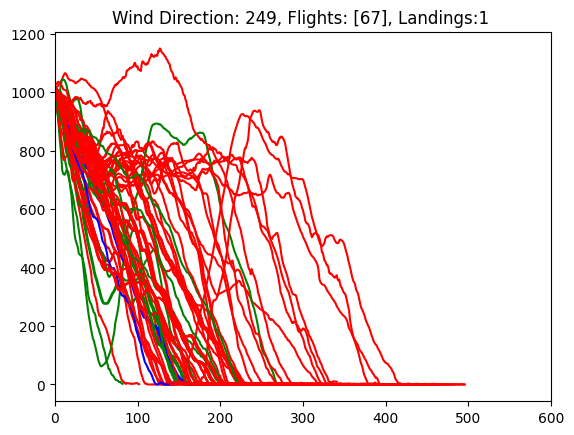

In [ ]:
files = glob.glob('../Figures/Empirical/Wind_Direction_Batch/*')
for f in files:
    os.remove(f)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
descentArray = [[] for _ in range(0,dfArray.__len__())]
headingAtLanding = []
fieldElevation = []
magneticVariation = []
crossWindComponent = []
minStep = 50
maxStep = 500

for x in range (0,90):
    currdf = dfArray[x]
    # x1 = 0
    # x2 = 50


    for stepCount in range(minStep,maxStep):
        step = stepCount
        altitudeDeltaThreshold = 800

        for xInner in range(0, currdf.__len__()-step, step):
            storageCount = 0
            x1 = xInner
            x2 = xInner+step
            delta = currdf['AltAGL'][x1] - currdf['AltAGL'][x2]
            if delta >= altitudeDeltaThreshold and currdf['AltAGL'][x2] <= 0 and currdf['AltAGL'][x1] > 0.0:
                # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                if(currdf['AltAGL'][x1] <= 1020 and currdf['AltAGL'][x1] >=1000):
                    # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                    newDataFrame = pd.DataFrame(currdf[:][x1:x2]).reset_index()
                    descentArray[x].append(newDataFrame)
                    headingAtLanding.append(currdf[' HDG'][x2]) #Heading at Landing
                    fieldElevation.append(currdf[' AltMSL'][x2]) #Field Elevation at Landing
                    magneticVariation.append(currdf[' MagVar'][x2])

                    ##Clearning Descent from array

                    # for i in range(x1,x2+1):
                    #     currdf['AltAGL'][i] = 0

                    # crossWindComponent.append(currdf[' WndSpd'][x2] * math.sin(currdf[' HDG'][x2]-currdf[' WndDr'][x2])) #Crosswind Component at Landing


                    storageCount+=1

        
        # descentArray[0].head()
        # x1 = xInner
        # x2 = xInner+step

descentArray.__len__()
# axes = descentArray[0]['AltAGL'].plot(kind='line', title='Altitude AGL Distribution',figsize=(15,3))
# descentArray[0][' HDG'].plot(ax=axes, kind='line')
# descentArray[0][' Roll'].plot(ax=axes, kind='line',secondary_y=True)
# descentArray[0][' Pitch'].plot(ax=axes, kind='line',secondary_y=True)
headingTolerance = 10
elevationTolerance = 2
magneticVariationTolerance = 1
minimumRunwayLength = 0
# print("Heading:",headingAtLanding[0],"----", "Elevation:",fieldElevation[0],"----", "Magnetic Variation:",magneticVariation[0])
# print(findRunway(headingAtLanding[0],fieldElevation[0],magneticVariation[0],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))

# descentArray[0][' GndSpd'].plot(ax=axes, kind='line', title='Altitude AGL Distribution',figsize=(15,3),secondary_y=True)
# axes = descentArray[0][' COM1'].plot( kind='hist', secondary_y=True)

colors =["red","green","blue","purple","orange","black"]

for x in range(0,directionBins.__len__()):
    numOfLandingsPlotted = 0
    for y in range(0,directionBins[x].__len__()):
        currFlight = directionBins[x][y]
        for descent in range(0,descentArray[currFlight].__len__()):
            plt.xlim(0,600)
            descentArray[currFlight][descent]['AltAGL'].plot( kind='line',color=(colors[y] if colors[y] else "black"))
            numOfLandingsPlotted+=1
            
            # descentArray[x][' HDG'].plot(ax=axes, kind='line',secondary_y=True)
            # print("Heading:",headingAtLanding[x],"----", "Elevation:",fieldElevation[x],"----", "Magnetic Variation:",magneticVariation[x])
            # print(findRunway(headingAtLanding[x],fieldElevation[x],magneticVariation[x],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))
            plt.title("Wind Direction: {}, Flights: {}, Landings:{} ".format(x,directionBins[x],numOfLandingsPlotted)) 
            plt.savefig("../Figures/Empirical/Wind_Direction_Batch/WindDirection_{}_Empirical_Analysis_{}.png".format(x,timestamp))
            plt.clf()
    # plt.show()


# Wind Speed Batch

In [22]:
files = glob.glob('../Figures/Empirical/Wind_Speed_Batch/*')
for f in files:
    os.remove(f)

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
for x in range(0,speedBins.__len__()):
    numOfLandingsPlotted2 = 0
    for y in range(0,speedBins[x].__len__()):
        currFlight = speedBins[x][y]
        for descent in range(0,descentArray[currFlight].__len__()):
            plt.xlim(0,600)
            descentArray[currFlight][descent]['AltAGL'].plot( kind='line',color=(colors[y] if colors[y] else "black"))
            numOfLandingsPlotted+=1
            # descentArray[x][' HDG'].plot(ax=axes, kind='line',secondary_y=True)
            # print("Heading:",headingAtLanding[x],"----", "Elevation:",fieldElevation[x],"----", "Magnetic Variation:",magneticVariation[x])
            # print(findRunway(headingAtLanding[x],fieldElevation[x],magneticVariation[x],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))
            plt.title("Wind Speed: {}, Flights: {}, Landings:{} ".format(x,speedBins[x],numOfLandingsPlotted2))  
            plt.savefig("../Figures/Empirical/Wind_Speed_Batch/WindSpeed_{}_Empirical_Analysis_{}.png".format(x,timestamp))
            plt.clf()
    # plt.show()

<Figure size 640x480 with 0 Axes>